# Model 3 – CTC Unit Recognition + WFST Lexicon Decoder

Model‑3 is the final and best-performing model in this project. It combines a neural unit recognition model with a structured WFST lexicon decoder for Myanmar handwriting recognition.

In the first stage, a BiLSTM encoder is trained with CTC to predict handwriting unit sequences from stroke embeddings. This allows the model to learn alignment-free unit recognition without requiring explicit stroke-to-unit segmentation.

In the second stage, the CTC model produces N-best candidate unit paths. These candidate unit sequences are then decoded using a WFST lexicon. The lexicon topology is generated from canonical syllable structure using `syl.txt`, `syllable_char_df`, and rule-based `char_array_to_units` conversion. The lexicon is then weighted using training unit-sequence statistics.

This design combines:
- **neural sequence learning** for robust handwriting recognition
- **symbolic lexicon decoding** for valid syllable structure

As a result, Model‑3 provides strong final recognition accuracy while remaining interpretable and suitable for CPU-only experiments.
```mermaid
flowchart TD
    A[Stroke embeddings] --> B[CTC Unit Model]
    B --> C[N-best unit paths]

    D[syl.txt + syllable_char_df] --> E[Canonical syllable dictionary]
    F[Train unit_seq statistics] --> G[WFST weights]
    E --> H[WFST Lexicon]
    G --> H

    C --> I[Compose with WFST]
    H --> I
    I --> J[Shortest path decoding]
    J --> K[Predicted syllable]
```


In [1]:
#Font for matplot

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/mm/Pyidaungsu-2.3_Regular.ttf"

fm.fontManager.addfont(font_path)

prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()

### DataSet Loading
Strokes ( series of x, y, timestamp ) infromation are load to Pandas Dataframe.

In [2]:
# @title Load Dataset
from load_dataset import get_syllable_df, load_all_strokes, build_train_df

syl_path = '../syl.txt'
hw_path = '../dataset/Aung_Hein/'

processed_df, syllable_df, stroke_df, char2idx, idx2char = build_train_df(syl_path, hw_path)

In [3]:
from writing_units import (
    WritingUnitConfig,
    add_unit_array_columns,
    summarize_unit_conversion,
    add_align_array_columns
)

unit_cfg = WritingUnitConfig(
    merge_base_asat=True,
    merge_virama_next_base=True,
    keep_unit_meta=True,
    annotate_role_in_unit_string=False,
)

processed_units_df = add_unit_array_columns(
    processed_df,
    char_array_col="char_array",
    syllable_col="syllable",
    config=unit_cfg,
)

processed_units_df = add_align_array_columns(processed_units_df)

processed_units_df['sample_index'] = processed_units_df.index

In [4]:
processed_df.columns

Index(['id', 'sample_id', 'strokes', 'num_strokes', 'max_stroke_len',
       'total_points', 'source_file', 'syllable', 'num_char', 'char_array',
       'padded_chars', 'encoded', 'mask'],
      dtype='object')

In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    processed_units_df,
    test_size=0.20,
    random_state=42,
    shuffle=True,
)

print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

Train rows: 10570
Test rows : 2643


In [6]:
syllable_df = (
    processed_units_df[["syllable", "char_array"]]
    .drop_duplicates("syllable")
    .reset_index(drop=True)
)

print("Num unique syllables:", len(syllable_df))

Num unique syllables: 4377


## Embedding

In [7]:
import embedding
import importlib
importlib.reload(embedding)

from embedding import embed_stroke_dataframe, stack_embeddings, StrokeEmbeddingConfig


train_emb_df = embed_stroke_dataframe(train_df)
test_emb_df  = embed_stroke_dataframe(test_df)
full_emb_df  = embed_stroke_dataframe(processed_units_df)

In [8]:
from nn_unit_wfst_from_chararray_pipeline import ModelConfig,DataPrepConfig,TrainConfig
data_cfg = DataPrepConfig(
    sample_index_col="sample_index",
    stroke_index_col="stroke_index",
    emb_col="embedding",
    syllable_col="syllable",
    unit_array_col="align_unit_array",
)

In [9]:
import numpy as np

ids = np.array(sorted(train_emb_df["sample_index"].unique()))
rng = np.random.default_rng(42)
rng.shuffle(ids)

n_val = max(1, int(0.1 * len(ids)))
val_ids = set(ids[:n_val])
train_ids = set(ids[n_val:])

train_emb_df_sub = train_emb_df[train_emb_df.sample_index.isin(train_ids)]
val_emb_df_sub   = train_emb_df[train_emb_df.sample_index.isin(val_ids)]

train_meta_df_sub = train_df[train_df.sample_index.isin(train_ids)]
val_meta_df_sub   = train_df[train_df.sample_index.isin(val_ids)]

train_syll_set = set(train_meta_df_sub["syllable"].astype(str).unique())

val_meta_df_seen = val_meta_df_sub[
    val_meta_df_sub["syllable"].astype(str).isin(train_syll_set)
].copy()

val_seen_ids = set(val_meta_df_seen["sample_index"].astype(int).tolist())

val_emb_df_seen = val_emb_df_sub[
    val_emb_df_sub["sample_index"].isin(val_seen_ids)
].copy()

print("Original val samples:", val_meta_df_sub["sample_index"].nunique())
print("Seen-only val samples:", val_meta_df_seen["sample_index"].nunique())
print("Dropped unseen val samples:", val_meta_df_sub["sample_index"].nunique() - val_meta_df_seen["sample_index"].nunique())

Original val samples: 1057
Seen-only val samples: 969
Dropped unseen val samples: 88


## Model Training

In [10]:
result_history = []

In [11]:
import importlib
import nn_unit_wfst_from_chararray_pipeline
importlib.reload(nn_unit_wfst_from_chararray_pipeline)


from nn_unit_wfst_from_chararray_pipeline import (
    run_ctc_wfst_pipeline,
    DataPrepConfig,
    ModelConfig,
    TrainConfig,
    DecodeConfig,
    BaselineUnitSeqConfig,
)

data_cfg = DataPrepConfig(
    sample_index_col="sample_index",
    stroke_index_col="stroke_index",
    emb_col="embedding",
    syllable_col="syllable",
    unit_array_col="align_unit_array",
)

model_cfg = ModelConfig(
    hidden_dim=128,
    enc_layers=2,
    enc_dropout=0.20,
    bidirectional=True,
)

train_cfg = TrainConfig(
    batch_size=32,
    epochs=40,
    lr=1e-3,
    weight_decay=1e-4,
    grad_clip=5.0,
    patience=7,
    device="cpu",
)

decode_cfg = DecodeConfig(
    beam_size=10,
    beam_token_topk=5,
    top_k=10,
    alpha_lexicon=1.0,
    beta_prior=0.10,
    variant_smoothing=0.5,
    syllable_smoothing=1.0,
    include_empirical_fallback=True,
)

seq_cfg = BaselineUnitSeqConfig(
    merge_e_aa=True,
    merge_e_tall_aa=True,
    merge_i_u=False,
    merge_base_asat=True,
    merge_tall_aa_asat=True,
    merge_nga_asat=True,
    merge_virama_next_base=True,
    merge_medial_ya_ha=True,
    merge_medial_pairs=True,
    merge_medial_triplets=False,
)

result = run_ctc_wfst_pipeline(
    train_emb_df=train_emb_df_sub,
    test_emb_df=val_emb_df_seen,
    train_meta_df=train_meta_df_sub,
    test_meta_df=val_meta_df_seen,
    syllable_txt_path="../syl.txt",
    syllable_char_df=syllable_df,
    data_cfg=data_cfg,
    model_cfg=model_cfg,
    train_cfg=train_cfg,
    decode_cfg=decode_cfg,
    seq_cfg=seq_cfg,
    save_path="ctc_wfst_from_chararray.pt",
)

In [12]:
print(result["unit_test_metrics"])
display(result["pred_metrics"])
print(result["pred_df"]["decode_mode"].value_counts(dropna=False))

{'loss': 0.10028314618230388, 'unit_seq_acc': 0.9411764705882353}


,metric,value
0,top1,0.948400
1,top3,0.976264
2,top5,0.976264
3,top10,0.976264
4,wfst_rate,0.995872
5,none_rate,0.004128


decode_mode
wfst    965
none      4
Name: count, dtype: int64


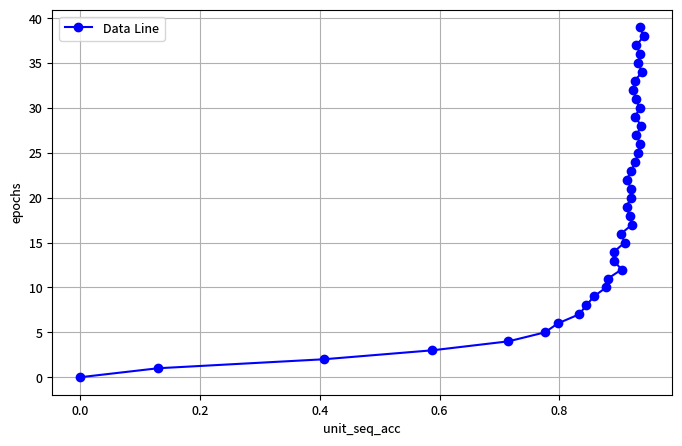

In [13]:
import matplotlib.pyplot as plt

metric = 'unit_seq_acc'
x = [ epoch['valid'][metric] for epoch in result["unit_train_history"] ]
y = range(len(result["unit_train_history"]))
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Data Line')

# Add labels, title, and legend
plt.xlabel(metric)
plt.ylabel('epochs')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [14]:
result['unit_test_metrics']

{'loss': 0.10028314618230388, 'unit_seq_acc': 0.9411764705882353}

In [15]:
result['pred_metrics']

,metric,value
0,top1,0.948400
1,top3,0.976264
2,top5,0.976264
3,top10,0.976264
4,wfst_rate,0.995872
5,none_rate,0.004128


In [16]:
import numpy as np

train_syll_set = set(train_df["syllable"].astype(str).unique())

test_meta_df_seen = test_df[
    test_df["syllable"].astype(str).isin(train_syll_set)
].copy()

test_seen_ids = set(test_meta_df_seen["sample_index"].astype(int).tolist())

test_emb_df_seen = test_emb_df[
    test_emb_df["sample_index"].isin(test_seen_ids)
].copy()

print("Original Test samples:", test_df["sample_index"].nunique())
print("Seen-only Test samples:", test_meta_df_seen["sample_index"].nunique())
print("Dropped unseen Test samples:", test_df["sample_index"].nunique() - test_meta_df_seen["sample_index"].nunique())

Original Test samples: 2643
Seen-only Test samples: 2550
Dropped unseen Test samples: 93


In [17]:
final_result_history = []
final_result = {}

### Load Model

In [18]:
import nn_unit_wfst_from_chararray_pipeline
importlib.reload(nn_unit_wfst_from_chararray_pipeline)

from nn_unit_wfst_from_chararray_pipeline import load_pipeline

artifacts4 = load_pipeline("ctc_wfst_from_chararray.pt", map_location="cpu")
print(artifacts4.keys())

dict_keys(['unit_model', 'unit2idx', 'idx2unit', 'lexicon_pkg', 'data_cfg', 'model_cfg', 'train_cfg', 'decode_cfg', 'seq_cfg', 'input_dim', 'pipeline_version'])


In [19]:
import nn_unit_wfst_from_chararray_pipeline
importlib.reload(nn_unit_wfst_from_chararray_pipeline)
from nn_unit_wfst_from_chararray_pipeline import predict_wfst_from_emb_df

pred_df4 = predict_wfst_from_emb_df(
    test_emb_df_seen,
    model=artifacts4["unit_model"],
    idx2unit=artifacts4["idx2unit"],
    lexicon_pkg=artifacts4["lexicon_pkg"],
    data_cfg=artifacts4["data_cfg"],
    infer_cfg=artifacts4["train_cfg"],
    decode_cfg=artifacts4["decode_cfg"],
    sample_meta_df=test_meta_df_seen,
)

display(pred_df4.head())
print(pred_df4["decode_mode"].value_counts(dropna=False))
print((pred_df4["pred_top1"] == pred_df4["true_syllable"]).mean())

,sample_index,pred_units,pred_top1,pred_topk,decode_mode,decode_distance,true_syllable,correct_top1
0,0,[အ],အ,"[အ, ဒ, အာ, ဘ, ဉ, ဌ, ဘာ]",wfst,0.882825,အ,True
1,8,"[က, ိ, ု]",ကို,"[ကို, ကု, ကိ]",wfst,0.844589,ကို,True
2,14,"[ပ, ါ]",ပါ,"[ပါ, ငါ, ပီ, ပွါ]",wfst,0.904413,ပါ,True
3,17,"[တ, ယ်]",တယ်,"[တယ်, တဏ်, တပ်, ထယ်, ဘယ်, ဝယ်, စယ်, တမ်]",wfst,0.844890,တယ်,True
4,19,"[သ, ည်]",သည်,"[သည်, သပ်, ထည်]",wfst,0.845009,သည်,True


decode_mode
wfst    2535
none      15
Name: count, dtype: int64
0.9423529411764706


In [20]:
import pandas as pd
import torch

from nn_unit_wfst_from_chararray_pipeline import ctc_greedy_decode, _to_device

@torch.no_grad()
def build_unit_prediction_df(model, loader, idx2unit, train_cfg):
    device = torch.device(train_cfg.device)
    model.to(device)
    model.eval()

    rows = []
    for batch in loader:
        batch = _to_device(batch, device)
        log_probs, out_lens = model(batch["x"], batch["x_lens"])

        pred_idx = ctc_greedy_decode(
            log_probs.detach().cpu(),
            out_lens.detach().cpu(),
            blank_idx=0,
        )
        pred_units = [[idx2unit[int(i)] for i in seq] for seq in pred_idx]

        for i in range(len(pred_units)):
            true_units = list(batch["y_units_list"][i])
            pred_units_i = list(pred_units[i])

            rows.append({
                "sample_index": batch["sample_index"][i],
                "true_syllable": batch["syllable"][i],
                "true_units": true_units,
                "pred_units_ctc": pred_units_i,
                "unit_exact_match": pred_units_i == true_units,
                "true_len": len(true_units),
                "pred_len": len(pred_units_i),
            })

    return pd.DataFrame(rows)

In [21]:
from torch.utils.data import DataLoader
from nn_unit_wfst_from_chararray_pipeline import (
    build_sample_table,
    UnitCTCDataset,
    collate_ctc,
    evaluate_unit_ctc,
)

# Build labeled test table
test_table = build_sample_table(
    test_emb_df_seen,
    sample_meta_df=test_meta_df_seen,
    cfg=data_cfg,
    require_units=True,
)

# Build test dataset / loader
test_ds = UnitCTCDataset(test_table, result["unit2idx"], data_cfg)
test_loader = DataLoader(
    test_ds,
    batch_size=train_cfg.batch_size,
    shuffle=False,
    num_workers=train_cfg.num_workers,
    collate_fn=collate_ctc,
)

# Evaluate raw CTC unit performance
test_unit_metrics = evaluate_unit_ctc(
    result["unit_model"],
    test_loader,
    idx2unit=result["idx2unit"],
    cfg=train_cfg,
)

print(test_unit_metrics)

{'loss': 0.13557810864319988, 'unit_seq_acc': 0.9364705882352942}


In [22]:
test_unit_pred_df = build_unit_prediction_df(
    result["unit_model"],
    test_loader,
    result["idx2unit"],
    train_cfg,
)

print("raw test unit_seq_acc =", test_unit_pred_df["unit_exact_match"].mean())
display(test_unit_pred_df.head())

raw test unit_seq_acc = 0.9364705882352942


,sample_index,true_syllable,true_units,pred_units_ctc,unit_exact_match,true_len,pred_len
0,0,အ,[အ],[အ],True,1,1
1,8,ကို,"[က, ိ, ု]","[က, ိ, ု]",True,3,3
2,14,ပါ,"[ပ, ါ]","[ပ, ါ]",True,2,2
3,17,တယ်,"[တ, ယ်]","[တ, ယ်]",True,2,2
4,19,သည်,"[သ, ည်]","[သ, ည်]",True,2,2


In [23]:
merged_df = pred_df4.merge(
    test_unit_pred_df,
    on=["sample_index", "true_syllable"],
    how="left",
)

display(merged_df.head())

,sample_index,pred_units,pred_top1,pred_topk,decode_mode,decode_distance,true_syllable,correct_top1,true_units,pred_units_ctc,unit_exact_match,true_len,pred_len
0,0,[အ],အ,"[အ, ဒ, အာ, ဘ, ဉ, ဌ, ဘာ]",wfst,0.882825,အ,True,[အ],[အ],True,1,1
1,8,"[က, ိ, ု]",ကို,"[ကို, ကု, ကိ]",wfst,0.844589,ကို,True,"[က, ိ, ု]","[က, ိ, ု]",True,3,3
2,14,"[ပ, ါ]",ပါ,"[ပါ, ငါ, ပီ, ပွါ]",wfst,0.904413,ပါ,True,"[ပ, ါ]","[ပ, ါ]",True,2,2
3,17,"[တ, ယ်]",တယ်,"[တယ်, တဏ်, တပ်, ထယ်, ဘယ်, ဝယ်, စယ်, တမ်]",wfst,0.844890,တယ်,True,"[တ, ယ်]","[တ, ယ်]",True,2,2
4,19,"[သ, ည်]",သည်,"[သည်, သပ်, ထည်]",wfst,0.845009,သည်,True,"[သ, ည်]","[သ, ည်]",True,2,2


In [24]:
print("overall top1 =", merged_df["correct_top1"].mean())
print("top1 when unit exact =", merged_df.loc[merged_df["unit_exact_match"], "correct_top1"].mean())
print("top1 when unit wrong =", merged_df.loc[~merged_df["unit_exact_match"], "correct_top1"].mean())

overall top1 = 0.9423529411764706
top1 when unit exact = 0.9937185929648241
top1 when unit wrong = 0.18518518518518517


In [25]:
bad_wfst_given_good_units = merged_df[
    (merged_df["unit_exact_match"] == True) &
    (merged_df["correct_top1"] == False)
].copy()


In [26]:
print("count =", len(bad_wfst_given_good_units))
display(
    bad_wfst_given_good_units[
        ["sample_index", "true_syllable", "true_units", "pred_units_ctc", "pred_top1", "pred_topk", "decode_distance"]
    ].head(30)
)

count = 15


,sample_index,true_syllable,true_units,pred_units_ctc,pred_top1,pred_topk,decode_distance
643,3305,ယောင်း,"[ေယ, ာ, င်, း]","[ေယ, ာ, င်, း]",ကာင်း,"[ကာင်း, ကောင်း]",8.386525
644,3307,ယောင်း,"[ေယ, ာ, င်, း]","[ေယ, ာ, င်, း]",None,[],NaN
787,4077,ငေါက်,"[ေင, ါ, က်]","[ေင, ါ, က်]",ဒေါက်,[ဒေါက်],9.008787
923,4794,ဖော,"[ေဖ, ာ]","[ေဖ, ာ]",ဃော,"[ဃော, ဗော, ဟော]",8.856107
1021,5406,ပြွမ်း,"[ပ, ြ, ွ, မ်, း]","[ပ, ြ, ွ, မ်, း]",None,[],NaN
1022,5407,ပြွမ်း,"[ပ, ြ, ွ, မ်, း]","[ပ, ြ, ွ, မ်, း]",None,[],NaN
1099,5814,ယိ,"[ယ, ိ]","[ယ, ိ]",ဃိ,"[ဃိ, ယိ, လိ, ဎိ, ပိ, ယံ, ဃံ, ယီ, ယ]",1.555802
1550,8137,စိန္တေ,"[စ, ိ, န, ္, ေတ]","[စ, ိ, န, ္, ေတ]",None,[],NaN
1864,9638,လျှား,"[လ, ျ, ှ, ာ, း]","[လ, ျ, ှ, ာ, း]",လျား,[လျား],7.531660
1875,9722,ဌော,"[ေဌ, ာ]","[ေဌ, ာ]",နော,"[နော, ဌေ]",5.736028


In [27]:
rescued_by_wfst = merged_df[
    (merged_df["unit_exact_match"] == False) &
    (merged_df["correct_top1"] == True)
].copy()

print("rescued count =", len(rescued_by_wfst))
display(
    rescued_by_wfst[
        ["sample_index", "true_syllable", "true_units", "pred_units_ctc", "pred_top1", "pred_topk", "decode_distance"]
    ].head(40)
)

rescued count = 30


,sample_index,true_syllable,true_units,pred_units_ctc,pred_top1,pred_topk,decode_distance
170,866,နော်,"[ေန, ာ, ်]","[ေန, ်]",နော်,"[နော်, နေက်, နေ့, နောက်]",3.655353
193,970,ရှင်း,"[ရ, ှ, င်, း]","[ဂ, ှ, င်, း]",ရှင်း,"[ရှင်း, ဂျင်း]",3.665559
200,1018,ဦး,"[ဥ, ီ, း]","[ဥ, း]",ဦး,"[ဦး, ခီး]",3.576554
280,1418,ဤ,[ဤ],"[က, ဤ]",ဤ,"[ဤ, ကဋ်, ကပ်, ဋ်, ပ်]",2.954883
605,3076,မည့်,"[မ, ည်, ့]","[မ, ည်, ်]",မည့်,"[မည့်, မည့်]",2.247309
635,3268,နွဲ့,"[န, ွ, ဲ, ့]","[ခ, ွ, ဲ, ့]",နွဲ့,"[နွဲ့, နှဲ့]",2.201228
654,3366,ညွန့်,"[ည, ွ, န်, ့]","[ည, န, ွ, န်, ့]",ညွန့်,[ညွန့်],2.220749
682,3495,တင့်,"[တ, င်, ့]","[တ, င, င်, ့]",တင့်,"[တင့်, တင့်]",2.279230
935,4861,ဉာ,"[ဉ, ာ]","[ဥ, ာ]",ဉာ,"[ဉာ, ဍာ, ဠာ, ဦ]",2.633739
1053,5577,ဈာန်,"[ဈ, ာ, န်]","[က, ျ, ာ, န်]",ဈာန်,"[ဈာန်, မာန်]",7.081701


In [41]:
unit_wrong_syllable_wrong = merged_df[
    (merged_df["unit_exact_match"] == False) &
    (merged_df["correct_top1"] == False)
].copy()

print("rescued count =", len(unit_wrong_syllable_wrong))
display(
    unit_wrong_syllable_wrong[
        ["sample_index", "true_syllable", "true_units", "pred_units_ctc", "pred_top1", "pred_topk", "decode_distance"]
    ].head(40)
)



rescued count = 132


,sample_index,true_syllable,true_units,pred_units_ctc,pred_top1,pred_topk,decode_distance
11,47,တွေ,"[တ, ွ, ေ]","[တ, ွ, ေ, ့]",တွေ့,"[တွေ့, တွေ, တေ့, တေ]",1.189078
15,63,ဖြစ်,"[ဖ, ြ, စ်]","[ပ, ြ, စ်]",ပြစ်,"[ပြစ်, ပစ်, ပျစ်, ဖြစ်, ပုစ်]",0.900143
30,114,လို့,"[လ, ိ, ု, ့]","[က, ိ, ု, ့]",ကို့,"[ကို့, လို့, ဂို့, ကို, စို့, လို, ဂို]",0.971038
40,177,ခု,"[ခ, ု]",[ဍ],ဍ,"[ဍ, ဥ, ဋ, န, ခ]",0.951035
64,321,နှ,"[န, ှ]",[ဒ],ဒ,"[ဒ, န, ဌ, ဠ, အ]",0.832802
109,538,၌,[၌],"[တ, တ်]",တတ်,"[တတ်, တွတ်, တဂ်, ဘတ်]",0.845486
125,624,ပတ်,"[ပ, တ်]","[ဝ, တ်]",ဝတ်,"[ဝတ်, ငတ်, ယတ်, ဝဂ်, ဝက်]",0.988353
132,676,ဘက်,"[ဘ, က်]","[အ, က်]",အက်,"[အက်, ဘက်, အဇ်, ဟက်, အဂ်]",1.468569
147,744,စော,"[ေစ, ာ]",[ေစ],စေ,"[စေ, စော, ဝေ, တေ, ဓေ, တော, ဓော, ဈေ]",1.475272
159,799,ရီး,"[ရ, ီ, း]","[ရ, ု, ံ, း]",ရုံး,"[ရုံး, ရီး]",1.402267


In [28]:
check_units_df = merged_df.copy()
check_units_df["pred_units_match"] = check_units_df["pred_units"].apply(list) == check_units_df["pred_units_ctc"].apply(list)
print(check_units_df["pred_units_match"].mean())

1.0


In [29]:
wrong_unit_df = merged_df[merged_df["unit_exact_match"] == False].copy()

wrong_unit_df["true_units_str"] = wrong_unit_df["true_units"].apply(lambda x: " ".join(x))
wrong_unit_df["pred_units_str"] = wrong_unit_df["pred_units_ctc"].apply(lambda x: " ".join(x))

mistake_counts = (
    wrong_unit_df.groupby(["true_units_str", "pred_units_str"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(mistake_counts.head(50))

,true_units_str,pred_units_str,count
112,ရ ှ ဉ ့ ်,ရ ှ ဉ ဉ် ်,2
40,ဉ,ဥ,2
32,စ ွ န် ့,စ ွ န ့ ်,2
35,ဆ ိ မ ့ ်,ဆ ိ မ် ့,2
133,အ ိ မ် ့,အ ိ မ ့,2
131,အ တ ္ထ ိ ု ပ ္ပ တ ္တ ိ,အ တ ္ထ ု ပ ္ပ တ ္တ ိ,2
4,က ျ ေ ာ က်,ေရ ာ က်,1
5,က ျ ွ င် ့,က ျ င ့ ်,1
0,က က ္က ု,က ဏ ္က ု,1
1,က ဏ ္ဍ ု,က ဏ ္ဍ ာ,1


In [30]:
train_unitseqs = {tuple(x) for x in result["train_table"]["unit_seq"]}
test_unit_pred_df["unit_seq_seen_in_train"] = test_unit_pred_df["true_units"].apply(lambda x: tuple(x) in train_unitseqs)

print("test unit-seq seen rate =", test_unit_pred_df["unit_seq_seen_in_train"].mean())
print("test unit-seq OOV rate =", 1.0 - test_unit_pred_df["unit_seq_seen_in_train"].mean())


test unit-seq seen rate = 0.9615686274509804
test unit-seq OOV rate = 0.03843137254901963


In [31]:
merged_df2 = merged_df.merge(
    test_unit_pred_df[["sample_index", "unit_seq_seen_in_train"]],
    on="sample_index",
    how="left"
)

print("top1 when true unit-seq seen in train =", merged_df2.loc[merged_df2["unit_seq_seen_in_train"], "correct_top1"].mean())
print("top1 when true unit-seq unseen in train =", merged_df2.loc[~merged_df2["unit_seq_seen_in_train"], "correct_top1"].mean())

top1 when true unit-seq seen in train = 0.9477977161500816
top1 when true unit-seq unseen in train = 0.8061224489795918


In [32]:
from collections import defaultdict

lex_map = defaultdict(set)
for e in result["lexicon_pkg"]["lex_entries"]:
    key = tuple(e["units"])
    lex_map[key].add(e["syllable"])

ambiguous_map = {k: v for k, v in lex_map.items() if len(v) > 1}

print("num ambiguous unit paths =", len(ambiguous_map))

for i, (k, v) in enumerate(list(ambiguous_map.items())[:20]):
    print(k, "->", sorted(v))

num ambiguous unit paths = 0


In [33]:
bad_wfst_given_good_units["true_units_tuple"] = bad_wfst_given_good_units["true_units"].apply(tuple)
bad_wfst_given_good_units["is_ambiguous_units"] = bad_wfst_given_good_units["true_units_tuple"].isin(set(ambiguous_map.keys()))

print(bad_wfst_given_good_units["is_ambiguous_units"].mean())

display(
    bad_wfst_given_good_units[
        ["sample_index", "true_syllable", "true_units", "pred_top1", "pred_topk", "is_ambiguous_units"]
    ].head(30)
)

0.0


,sample_index,true_syllable,true_units,pred_top1,pred_topk,is_ambiguous_units
643,3305,ယောင်း,"[ေယ, ာ, င်, း]",ကာင်း,"[ကာင်း, ကောင်း]",False
644,3307,ယောင်း,"[ေယ, ာ, င်, း]",None,[],False
787,4077,ငေါက်,"[ေင, ါ, က်]",ဒေါက်,[ဒေါက်],False
923,4794,ဖော,"[ေဖ, ာ]",ဃော,"[ဃော, ဗော, ဟော]",False
1021,5406,ပြွမ်း,"[ပ, ြ, ွ, မ်, း]",None,[],False
1022,5407,ပြွမ်း,"[ပ, ြ, ွ, မ်, း]",None,[],False
1099,5814,ယိ,"[ယ, ိ]",ဃိ,"[ဃိ, ယိ, လိ, ဎိ, ပိ, ယံ, ဃံ, ယီ, ယ]",False
1550,8137,စိန္တေ,"[စ, ိ, န, ္, ေတ]",None,[],False
1864,9638,လျှား,"[လ, ျ, ှ, ာ, း]",လျား,[လျား],False
1875,9722,ဌော,"[ေဌ, ာ]",နော,"[နော, ဌေ]",False


In [34]:
num_exact_units = merged_df["unit_exact_match"].sum()
num_exact_units_wrong_top1 = ((merged_df["unit_exact_match"] == True) & (merged_df["correct_top1"] == False)).sum()

print("exact-unit samples =", num_exact_units)
print("exact-unit but wrong WFST top1 =", num_exact_units_wrong_top1)
print("rate =", num_exact_units_wrong_top1 / max(num_exact_units, 1))

exact-unit samples = 2388
exact-unit but wrong WFST top1 = 15
rate = 0.00628140703517588


In [35]:
bad_cases = merged_df[merged_df["correct_top1"] == False].copy()

bad_cases["true_units_str"] = bad_cases["true_units"].apply(lambda x: " ".join(x))
bad_cases["pred_units_str"] = bad_cases["pred_units_ctc"].apply(lambda x: " ".join(x))
bad_cases["pred_topk_str"] = bad_cases["pred_topk"].apply(lambda x: ", ".join(map(str, x)))

display(
    bad_cases[
        [
            "sample_index",
            "true_syllable",
            "pred_top1",
            "pred_topk_str",
            "true_units_str",
            "pred_units_str",
            "unit_exact_match",
            "decode_distance",
        ]
    ].head(20)
)

,sample_index,true_syllable,pred_top1,pred_topk_str,true_units_str,pred_units_str,unit_exact_match,decode_distance
11,47,တွေ,တွေ့,"တွေ့, တွေ, တေ့, တေ",တ ွ ေ,တ ွ ေ ့,False,1.189078
15,63,ဖြစ်,ပြစ်,"ပြစ်, ပစ်, ပျစ်, ဖြစ်, ပုစ်",ဖ ြ စ်,ပ ြ စ်,False,0.900143
30,114,လို့,ကို့,"ကို့, လို့, ဂို့, ကို, စို့, လို, ဂို",လ ိ ု ့,က ိ ု ့,False,0.971038
40,177,ခု,ဍ,"ဍ, ဥ, ဋ, န, ခ",ခ ု,ဍ,False,0.951035
64,321,နှ,ဒ,"ဒ, န, ဌ, ဠ, အ",န ှ,ဒ,False,0.832802
109,538,၌,တတ်,"တတ်, တွတ်, တဂ်, ဘတ်",၌,တ တ်,False,0.845486
125,624,ပတ်,ဝတ်,"ဝတ်, ငတ်, ယတ်, ဝဂ်, ဝက်",ပ တ်,ဝ တ်,False,0.988353
132,676,ဘက်,အက်,"အက်, ဘက်, အဇ်, ဟက်, အဂ်",ဘ က်,အ က်,False,1.468569
147,744,စော,စေ,"စေ, စော, ဝေ, တေ, ဓေ, တော, ဓော, ဈေ",ေစ ာ,ေစ,False,1.475272
159,799,ရီး,ရုံး,"ရုံး, ရီး",ရ ီ း,ရ ု ံ း,False,1.402267


In [36]:
print("==== SUMMARY ====")
print("raw unit_seq_acc =", test_unit_pred_df["unit_exact_match"].mean())
print("overall top1 =", merged_df["correct_top1"].mean())
print("top1 | unit exact =", merged_df.loc[merged_df["unit_exact_match"], "correct_top1"].mean())
print("top1 | unit wrong =", merged_df.loc[~merged_df["unit_exact_match"], "correct_top1"].mean())
print("unit-seq OOV rate =", 1.0 - test_unit_pred_df["unit_seq_seen_in_train"].mean())
print("num ambiguous unit paths =", len(ambiguous_map))
print("decode mode counts:")
print(result["pred_df"]["decode_mode"].value_counts(dropna=False))

==== SUMMARY ====
raw unit_seq_acc = 0.9364705882352942
overall top1 = 0.9423529411764706
top1 | unit exact = 0.9937185929648241
top1 | unit wrong = 0.18518518518518517
unit-seq OOV rate = 0.03843137254901963
num ambiguous unit paths = 0
decode mode counts:
decode_mode
wfst    965
none      4
Name: count, dtype: int64


In [37]:
result = run_ctc_wfst_pipeline(
    train_emb_df=train_emb_df_sub,
    test_emb_df=test_emb_df_seen,
    train_meta_df=train_meta_df_sub,
    test_meta_df=test_meta_df_seen,
    syllable_txt_path="../syl.txt",
    syllable_char_df=syllable_df,
    data_cfg=data_cfg,
    model_cfg=model_cfg,
    train_cfg=train_cfg,
    decode_cfg=decode_cfg,
    seq_cfg=seq_cfg
)

In [38]:
result['pred_metrics']

,metric,value
0,top1,0.942745
1,top3,0.971373
2,top5,0.972157
3,top10,0.972157
4,wfst_rate,0.996078
5,none_rate,0.003922


In [39]:
result['unit_test_metrics']

{'loss': 0.12926463606310826, 'unit_seq_acc': 0.9298039215686275}

In [40]:
import pandas as pd
import numpy as np

# merged_df must contain:
# - unit_exact_match   : bool
# - correct_top1       : bool

case_df = merged_df.copy()

case_df["case"] = np.select(
    [
        (case_df["unit_exact_match"] == True)  & (case_df["correct_top1"] == True),
        (case_df["unit_exact_match"] == True)  & (case_df["correct_top1"] == False),
        (case_df["unit_exact_match"] == False) & (case_df["correct_top1"] == False),
        (case_df["unit_exact_match"] == False) & (case_df["correct_top1"] == True),
    ],
    [
        "unit_correct_syllable_correct",
        "unit_correct_syllable_wrong",
        "unit_wrong_syllable_wrong",
        "unit_wrong_syllable_correct",
    ],
    default="unknown"
)

case_summary_df = (
    case_df["case"]
    .value_counts(dropna=False)
    .rename_axis("case")
    .reset_index(name="count")
)

case_summary_df["ratio"] = case_summary_df["count"] / case_summary_df["count"].sum()

# Optional: enforce order
case_order = [
    "unit_correct_syllable_correct",
    "unit_correct_syllable_wrong",
    "unit_wrong_syllable_wrong",
    "unit_wrong_syllable_correct",
]

case_summary_df["case"] = pd.Categorical(
    case_summary_df["case"],
    categories=case_order,
    ordered=True,
)

case_summary_df = case_summary_df.sort_values("case").reset_index(drop=True)

display(case_summary_df)


,case,count,ratio
0,unit_correct_syllable_correct,2373,0.930588
1,unit_correct_syllable_wrong,15,0.005882
2,unit_wrong_syllable_wrong,132,0.051765
3,unit_wrong_syllable_correct,30,0.011765
